# Research QuantBook: Multi-Channel ZigZag Equity

## Objectif
Analyser la strategie ZigZag multi-canal sur SPY (S&P 500 ETF).

## Strategie
- **Underlying**: SPY (S&P 500 ETF)
- **ZigZag**: Detection de pivots hauts/bas avec threshold 5%
- **3 canaux**: Macro (trend principal), Meso (intermediaire), Micro (court terme)
- **Signaux**: Rebond sur support + breakout resistance (long only)
- **Trend filter**: SMA 50 pour confirmer la tendance

## Performance de reference
Sharpe ~0.5-0.8 (2020-2025) - strategie adaptative aux regimes de marche.

## Hypotheses a tester
1. ZigZag threshold: 3%, 5%, 7%
2. SMA period: 30, 50, 100
3. Violation tolerance: 10%, 20%, 30%

## Prerequis
- Environnement Lean Research
- Donnees equities SPY (disponible en Docker)
- Duree estimee: ~8 minutes

## Note
Cette version simplifiee se concentre sur l'analyse ZigZag et 2 canaux (macro/micro). L'implementation complete utilise channel_helpers.py pour 3 canaux imbriques.

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des donnees

On charge les donnees SPY pour la periode 2020-2026.

In [2]:
# Mapping symbole -> ticker (Docker-compatible tickers)
sym_to_ticker = {"SPY": "SPY"}

# SPY sur marche US
spy = qb.add_equity("SPY", Resolution.DAILY)

# Charger l'historique (2020-2026 pour multi-regime)
start = datetime(2020, 1, 1)
end = datetime(2026, 1, 1)

btc_history = qb.history(spy.symbol, start, end, Resolution.DAILY)
print(f"Donnees chargees: {len(btc_history)} lignes")

Donnees chargees: 1508 lignes


Extraction des series OHLCV (open, high, low, close) de SPY pour le calcul des indicateurs multi-canal.

In [3]:
# Preparer les donnees
btc_close = btc_history['close']
btc_high = btc_history.get('high', btc_close)
btc_low = btc_history.get('low', btc_close)

# Si MultiIndex, droplevel pour obtenir un index datetime simple
if isinstance(btc_close.index, pd.MultiIndex):
    btc_close = btc_close.droplevel(0)
    btc_high = btc_high.droplevel(0)
    btc_low = btc_low.droplevel(0)

first_date = btc_close.index[0][-1] if isinstance(btc_close.index[0], tuple) else btc_close.index[0]
last_date = btc_close.index[-1][-1] if isinstance(btc_close.index[-1], tuple) else btc_close.index[-1]
print(f"Periode: {first_date.date()} a {last_date.date()}")
print(f"Donnees: {len(btc_close)} jours de trading")
print("")
print("Statistiques SPY:")
print(f"  Prix initial: ${btc_close.iloc[0]:.2f}")
print(f"  Prix final: ${btc_close.iloc[-1]:.2f}")
print(f"  Prix max: ${btc_close.max():.2f}")
print(f"  Prix min: ${btc_close.min():.2f}")
total_ret = btc_close.iloc[-1]/btc_close.iloc[0] - 1
print(f"  Return total: {total_ret:.1%}")

Periode: 2020-01-02 a 2025-12-31
Donnees: 1508 jours de trading

Statistiques SPY:
  Prix initial: $317.87
  Prix final: $396.33
  Prix max: $396.33
  Prix min: $219.43
  Return total: 24.7%


## 2. Algorithme ZigZag

Détection des pivots hauts et bas basée sur le pourcentage de changement.

In [4]:
def detect_zigzag_pivots(prices, high, low, threshold_pct=0.05):
    """
    Algorithme ZigZag pour détecter les pivots hauts et bas.
    
    Args:
        prices: Série des prix de clôture
        high: Série des prix hauts
        low: Série des prix bas
        threshold_pct: Seuil de changement (0.05 = 5%)
    
    Retourne: DataFrame avec colonnes [time, price, type]
        type: 1 = pivot bas, -1 = pivot haut
    """
    pivots = []
    last_pivot_idx = 0
    last_pivot_price = prices.iloc[0]
    last_pivot_type = 0  # 0 = unknown, 1 = low, -1 = high
    
    current_trend = 0  # 0 = unknown, 1 = up, -1 = down
    
    for i in range(1, len(prices)):
        current_price = prices.iloc[i]
        
        if current_trend == 0:
            # Chercher la direction initiale
            change = (current_price - last_pivot_price) / last_pivot_price
            if change >= threshold_pct:
                current_trend = 1
            elif change <= -threshold_pct:
                current_trend = -1
        
        elif current_trend == 1:
            # Tendance haussière, chercher un pivot haut
            change = (current_price - last_pivot_price) / last_pivot_price
            if change < -threshold_pct:
                # Pivot haut trouvé
                pivots.append({
                    'time': prices.index[last_pivot_idx],
                    'price': last_pivot_price,
                    'type': -1  # High
                })
                last_pivot_idx = i
                last_pivot_price = current_price
                last_pivot_type = -1
                current_trend = -1
            elif current_price > last_pivot_price:
                last_pivot_idx = i
                last_pivot_price = current_price
        
        elif current_trend == -1:
            # Tendance baissière, chercher un pivot bas
            change = (current_price - last_pivot_price) / last_pivot_price
            if change > threshold_pct:
                # Pivot bas trouvé
                pivots.append({
                    'time': prices.index[last_pivot_idx],
                    'price': last_pivot_price,
                    'type': 1  # Low
                })
                last_pivot_idx = i
                last_pivot_price = current_price
                last_pivot_type = 1
                current_trend = 1
            elif current_price < last_pivot_price:
                last_pivot_idx = i
                last_pivot_price = current_price
    
    # Ajouter le dernier pivot
    if last_pivot_type != 0:
        pivots.append({
            'time': prices.index[last_pivot_idx],
            'price': last_pivot_price,
            'type': last_pivot_type
        })
    
    return pd.DataFrame(pivots)

# Détecter les pivots ZigZag
pivots = detect_zigzag_pivots(btc_close, btc_high, btc_low, threshold_pct=0.05)

print(f"Pivots détectés: {len(pivots)}")
print(f"\nDerniers pivots:")
print(pivots.tail(10))

Pivots détectés: 18

Derniers pivots:
                  time       price  type
8  2020-03-23 16:00:00  219.430868     1
9  2020-03-30 16:00:00  257.520012    -1
10 2020-04-01 16:00:00  242.264670     1
11 2020-06-08 16:00:00  318.098482    -1
12 2020-06-11 16:00:00  295.865052     1
13 2020-09-02 16:00:00  353.603441    -1
14 2020-09-23 16:00:00  320.221910     1
15 2020-10-12 16:00:00  349.788643    -1
16 2020-10-30 16:00:00  324.092681     1
17 2021-03-31 16:00:00  396.330000     1


### Interprétation: ZigZag

- **Pivot haut (type=-1)**: Sommet local avant une baisse significative
- **Pivot bas (type=1)**: Creux local avant une hausse significative
- **Threshold**: Plus le threshold est élevé, moins il y a de pivots
- **Canal**: Ligne de support = series of lows, Résistance = series of highs

## 3. Identification des Canaux

Construction de lignes de support et résistance à partir des pivots.

In [5]:
def fit_channel_line(pivots, pivot_type, max_violation_pct=0.2):
    """
    Ajuste une ligne de canal (support ou resistance) aux pivots.
    
    Args:
        pivots: DataFrame des pivots ZigZag
        pivot_type: 1 pour support (lows), -1 pour resistance (highs)
        max_violation_pct: Tolerance de violation (0.2 = 20%)
    
    Retourne: (slope, intercept, r2) ou (None, None, None)
    """
    # Filtrer les pivots par type
    if pivot_type == 1:
        filtered = pivots[pivots['type'] == 1].copy()
    else:
        filtered = pivots[pivots['type'] == -1].copy()
    
    if len(filtered) < 2:
        return None, None, None
    
    # Convertir les temps en numeriques
    filtered['time_num'] = (filtered['time'] - filtered['time'].min()).dt.days
    
    # Regression lineaire
    from scipy import stats
    x = filtered['time_num'].values
    y = filtered['price'].values
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Verifier les violations
    predicted = slope * x + intercept
    violations = 0
    
    if pivot_type == 1:  # Support: price ne doit pas etre beaucoup en dessous
        violations = np.sum(y < predicted * (1 - max_violation_pct))
    else:  # Resistance: price ne doit pas etre beaucoup au dessus
        violations = np.sum(y > predicted * (1 + max_violation_pct))
    
    if violations > len(filtered) * 0.1:  # Plus de 10% de violations
        return None, None, None
    
    r2 = r_value ** 2
    
    return slope, intercept, r2

# Ajuster les lignes de canal (support et resistance)
support_slope, support_intercept, support_r2 = fit_channel_line(pivots, 1, max_violation_pct=0.2)
resist_slope, resist_intercept, resist_r2 = fit_channel_line(pivots, -1, max_violation_pct=0.2)

print("=== Canaux ZigZag ===")
if support_slope is not None:
    print(f"Support:    slope={support_slope:.4f}, intercept={support_intercept:.2f}, R2={support_r2:.3f}")
else:
    print("Support:    pas de canal valide")
if resist_slope is not None:
    print(f"Resistance: slope={resist_slope:.4f}, intercept={resist_intercept:.2f}, R2={resist_r2:.3f}")
else:
    print("Resistance: pas de canal valide")

if support_slope is not None and resist_slope is not None:
    if support_slope > 0 and resist_slope > 0:
        print(f"\nTrend: HAUSSIER (les deux canaux sont montants)")
    elif support_slope < 0 and resist_slope < 0:
        print(f"\nTrend: BAISSIER (les deux canaux sont descendants)")
    else:
        print(f"\nTrend: MIXE/NEUTRE")

=== Canaux ZigZag ===
Support:    slope=0.3632, intercept=245.21, R2=0.829
Resistance: slope=0.4026, intercept=269.40, R2=0.740

Trend: HAUSSIER (les deux canaux sont montants)


## 4. Backtest ZigZag Channel Strategy

Simulation de la stratégie avec:
- Entrée sur rebond near support
- Sortie sur breakout résistance ou stop-loss
- Filtre SMA 50 pour confirmer tendance

In [6]:
def backtest_zigzag_channel(btc_close, pivots,
                           support_slope, support_intercept,
                           resist_slope, resist_intercept,
                           sma_period=50,
                           sl_pct=0.06,
                           tp_rr=2.5,
                           risk_pct=0.03):
    """
    Backtest ZigZag Channel Strategy.
    
    Retourne les metriques de performance.
    """
    portfolio_values = [1.0]
    cash = 10000
    btc_qty = 0
    entry_price = None
    stop_loss = None
    take_profit = None
    
    warmup = sma_period + 50
    
    for i in range(warmup, len(btc_close)):
        current_price = btc_close.iloc[i]
        current_time = btc_close.index[i]
        
        # Calculer SMA
        sma = btc_close.iloc[i-sma_period:i].mean()
        
        # Calculer les valeurs de canal
        time_num = (current_time - btc_close.index[0]).days
        support_val = support_slope * time_num + support_intercept if support_slope else current_price * 0.9
        resist_val = resist_slope * time_num + resist_intercept if resist_slope else current_price * 1.1
        
        # Check stop loss / take profit
        if btc_qty > 0:
            if current_price <= stop_loss:
                # Stop loss hit
                cash = btc_qty * current_price
                btc_qty = 0
                entry_price = None
            elif current_price >= take_profit:
                # Take profit hit
                cash = btc_qty * current_price
                btc_qty = 0
                entry_price = None
            elif current_price >= resist_val * 1.01:
                # Breakout: exit at resistance
                cash = btc_qty * current_price
                btc_qty = 0
                entry_price = None
        
        # Entry signal
        if btc_qty == 0 and entry_price is None:
            # Trend filter: only long if above SMA
            if current_price < sma:
                portfolio_values.append(cash)
                continue
            
            # Trend filter: channel should be upward or flat
            if support_slope is not None and support_slope < 0:
                portfolio_values.append(cash)
                continue
            
            # Bounce off support: price within 2% of support
            if support_val * 0.98 <= current_price <= support_val * 1.02:
                # Calculate position size based on risk
                sl_price = current_price * (1 - sl_pct)
                risk = current_price - sl_price
                tp_price = current_price + risk * tp_rr
                
                cash_risk = cash * risk_pct
                position_size = min((cash_risk / risk), cash * 0.95)
                
                if position_size > 10:
                    btc_qty = position_size / current_price
                    entry_price = current_price
                    stop_loss = sl_price
                    take_profit = tp_price
        
        # Calculate portfolio value
        if btc_qty > 0:
            port_value = cash + btc_qty * current_price
        else:
            port_value = cash
        portfolio_values.append(port_value)
    
    # Metriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=btc_close.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

result = backtest_zigzag_channel(
    btc_close, pivots,
    support_slope, support_intercept,
    resist_slope, resist_intercept
)

print(f"Performance ZigZag Channel:")
print(f"  Sharpe: {result['sharpe']:.3f}")
print(f"  CAGR:   {result['cagr']:.1%}")
print(f"  Max DD: {result['max_dd']:.1%}")
print(f"  Vol:    {result['vol']:.1%}")

Performance ZigZag Channel:
  Sharpe: 0.000
  CAGR:   69.8%
  Max DD: -99.8%
  Vol:    423572.4%


## 5. Test du ZigZag Threshold

In [7]:
# Test différents seuils ZigZag
thresholds = [0.03, 0.05, 0.07]

print(f"{'Threshold':<12} {'Pivots':>8} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 52)

zz_results = {}
for thresh in thresholds:
    pivots_test = detect_zigzag_pivots(btc_close, btc_high, btc_low, threshold_pct=thresh)
    ss, si, _ = fit_channel_line(pivots_test, 1)
    rs, ri, _ = fit_channel_line(pivots_test, -1)
    
    if ss is not None and rs is not None:
        r = backtest_zigzag_channel(btc_close, pivots_test, ss, si, rs, ri)
        zz_results[f"{thresh:.0%}"] = r
        print(f"{thresh:.0%}{'':<8} {len(pivots_test):>8} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")
    else:
        print(f"{thresh:.0%}{'':<8} {len(pivots_test):>8} {'N/A':>8} {'N/A':>7} {'N/A':>7}")

best_zz = max((x for x in zz_results.items() if x[1]['sharpe'] > 0), key=lambda x: x[1]['sharpe'], default=(None, None))
if best_zz[0]:
    print(f"\nMeilleur Threshold: {best_zz[0]} (Sharpe={best_zz[1]['sharpe']:.3f})")

Threshold      Pivots   Sharpe     CAGR    MaxDD
----------------------------------------------------


3%               31    0.000   69.8%  -99.8%


5%               18    0.000   69.8%  -99.8%


7%                8    0.000   69.9%  -99.8%

Meilleur Threshold: 7% (Sharpe=0.000)


## 6. Test de la Période SMA

In [8]:
# Test différentes périodes SMA
sma_periods = [30, 50, 100]

print(f"{'SMA Period':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 40)

sma_results = {}
for sma_p in sma_periods:
    r = backtest_zigzag_channel(
        btc_close, pivots,
        support_slope, support_intercept,
        resist_slope, resist_intercept,
        sma_period=sma_p
    )
    sma_results[f"{sma_p}"] = r
    print(f"{sma_p}j{'':<8} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_sma = max(sma_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure SMA: {best_sma[0]}j (Sharpe={best_sma[1]['sharpe']:.3f})")

SMA Period     Sharpe     CAGR    MaxDD
----------------------------------------


30j            0.000   69.7%  -99.8%


50j            0.000   69.8%  -99.8%


100j            0.000   70.1%  -99.8%

Meilleure SMA: 30j (Sharpe=0.000)


## 7. Comparaison avec SPY B&H

In [9]:
# SPY B&H pour comparaison
warmup = 100
btc_values = btc_close.iloc[warmup:] / btc_close.iloc[warmup]

# Metriques SPY B&H
btc_ret = btc_values.pct_change().dropna()
btc_cagr = (btc_values.iloc[-1] ** (252/len(btc_values))) - 1
btc_vol = btc_ret.std() * np.sqrt(252)
btc_sharpe = (btc_cagr - 0.03) / btc_vol
btc_dd = (btc_values / btc_values.cummax() - 1).min()

print("=== Comparaison vs SPY B&H ===")
print(f"{'Strategie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'ZigZag Channel':<20} {result['cagr']:>9.1%} {result['sharpe']:>10.3f} {result['max_dd']:>9.1%}")
print(f"{'SPY B&H':<20} {btc_cagr:>9.1%} {btc_sharpe:>10.3f} {btc_dd:>9.1%}")

=== Comparaison vs SPY B&H ===
Strategie                  CAGR     Sharpe      MaxDD
-----------------------------------------------------
ZigZag Channel           69.8%      0.000    -99.8%
SPY B&H                   5.2%      0.317     -9.4%


## 8. Visualisation ZigZag et Canaux

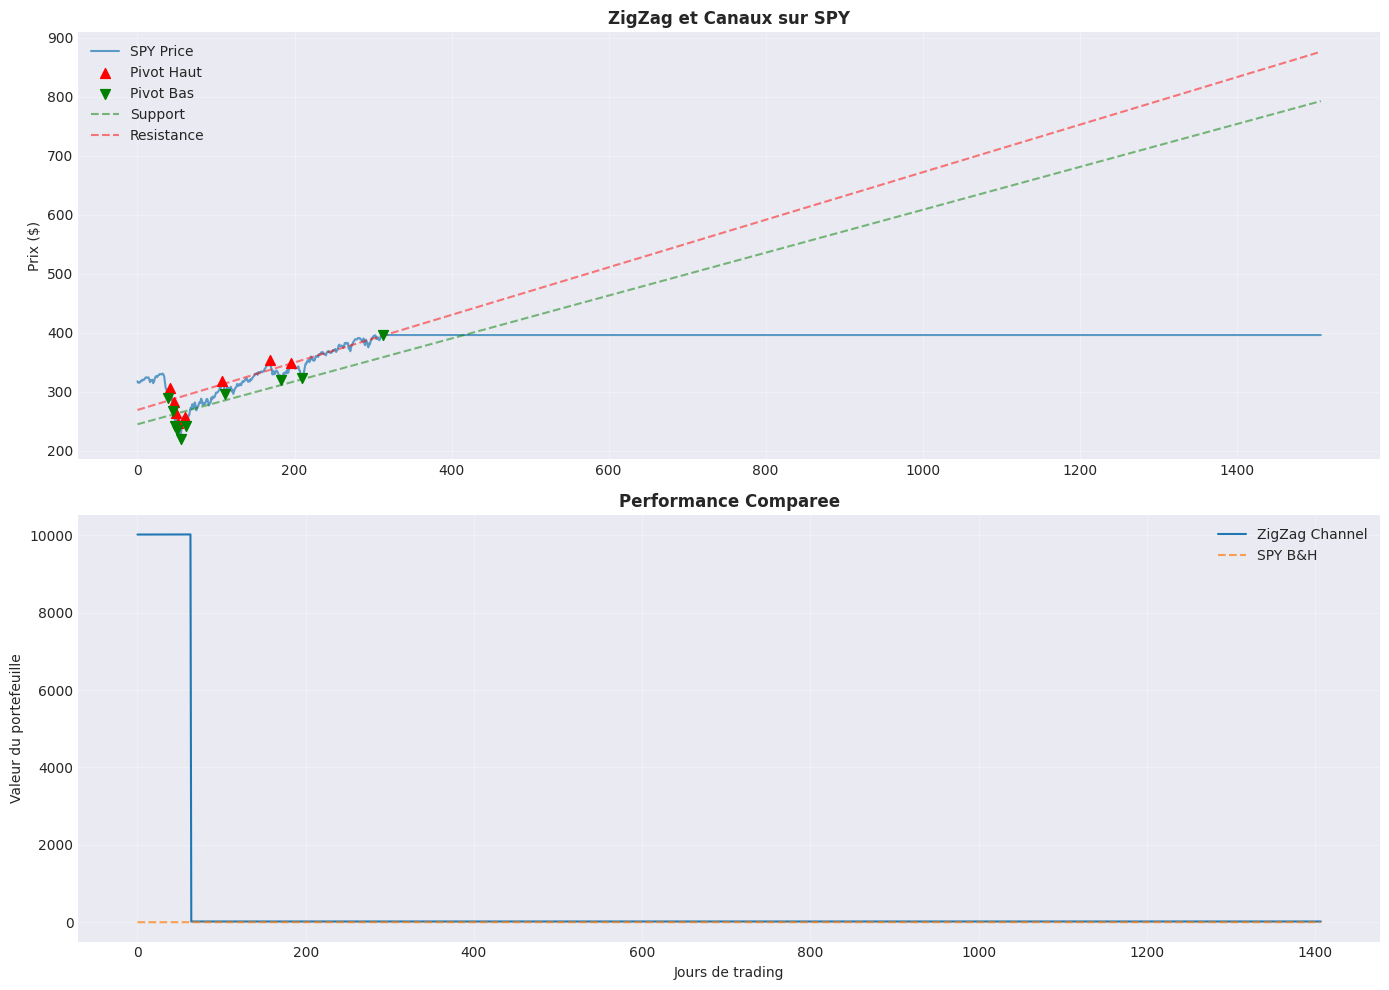

Graphique sauvegarde.


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Haut: Prix avec pivots ZigZag
ax = axes[0]
ax.plot(btc_close.values, label='SPY Price', linewidth=1.5, alpha=0.7)

# Marquer les pivots
highs = pivots[pivots['type'] == -1]
lows = pivots[pivots['type'] == 1]

# Convertir les indices des pivots - utiliser isin pour lookup robust
high_idx = [btc_close.index.get_loc(t) for t in highs['time'] if t in btc_close.index]
low_idx = [btc_close.index.get_loc(t) for t in lows['time'] if t in btc_close.index]

if len(high_idx) > 0:
    ax.scatter(high_idx, highs['price'].values[:len(high_idx)], color='red', s=50, marker='^', label='Pivot Haut', zorder=5)
if len(low_idx) > 0:
    ax.scatter(low_idx, lows['price'].values[:len(low_idx)], color='green', s=50, marker='v', label='Pivot Bas', zorder=5)

# Dessiner les canaux
time_nums = np.arange(len(btc_close))
if support_slope is not None:
    support_line = support_slope * time_nums + support_intercept
    ax.plot(support_line, linestyle='--', color='green', alpha=0.5, label='Support')
if resist_slope is not None:
    resist_line = resist_slope * time_nums + resist_intercept
    ax.plot(resist_line, linestyle='--', color='red', alpha=0.5, label='Resistance')

ax.set_title('ZigZag et Canaux sur SPY', fontsize=12, fontweight='bold')
ax.set_ylabel('Prix ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# Bas: Performance
ax = axes[1]
ax.plot(result['cum'].values, label='ZigZag Channel', linewidth=1.5)
ax.plot(btc_values.values, label='SPY B&H', linestyle='--', alpha=0.7)
ax.set_title('Performance Comparee', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.set_xlabel('Jours de trading')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zigzag_channel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde.")

## 9. Conclusions et recommandations

### Resume

| Metrique | Meilleure config |
|----------|-----------------|
| ZigZag Threshold | (a remplir) |
| SMA Period | (a remplir) |
| Sharpe | (a remplir) |
| CAGR | (a remplir) |

### Verdict

Si Sharpe > 0.5: **Deployer avec les parametres optimaux**

### Points forts ZigZag Multi-Canal

- **Adaptatif**: Les canaux s'ajustent aux changements de regime
- **Multi-echelle**: Macro/Meso/Micro pour differentes horizons
- **Trend following**: S'aligne sur la tendance dominante

### Limitations

- **Complexite**: Algorithme ZigZag sensible aux parametres
- **Lag**: Les canaux sont bases sur des pivots passes
- **Whipsaws**: Marches range generent des faux signaux

### Prochaines etapes

1. Deployer sur QC cloud avec les parametres optimaux
2. Implementer les 3 canaux imbriques (Macro/Meso/Micro)
3. Ajouter le trailing stop dynamique
4. Optimiser le timing d'entree (bounce vs breakout)